In [38]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import copy
from skimage.metrics import structural_similarity, mean_squared_error

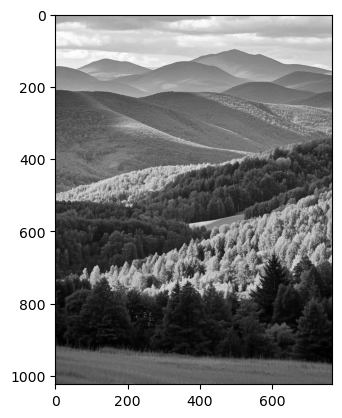

In [2]:
image = cv2.imread('hills.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

plt.imshow(image_gray, cmap='gray')

# Наложение шума Гаусса и постоянного шума

In [12]:
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

array([[217,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,  22, 162, 171],
       [  0,   0,   0, ..., 117,  22, 181],
       ...,
       [  0,   0,  87, ...,   0, 176, 139],
       [  0,   0,  13, ...,  65,  60,  91],
       [236,   0,  63, ...,  20,   0, 223]],
      shape=(1024, 768), dtype=uint8)

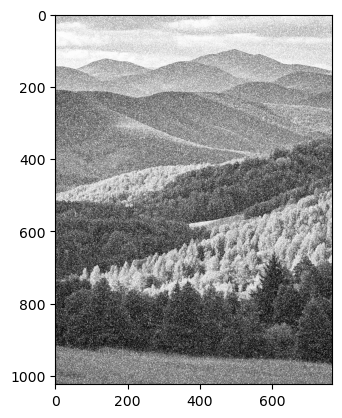

In [39]:
image_noise_gauss = cv2.add(image_gray, noise_gauss)

plt.imshow(image_noise_gauss, cmap='gray')

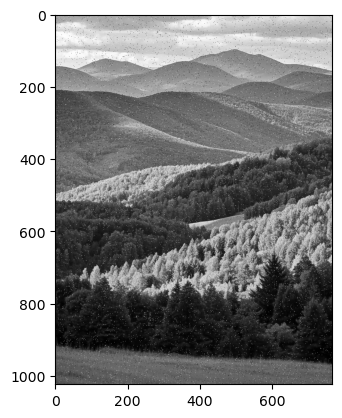

In [35]:
# salt and pepper
noise =  np.random.randint(0, 101, size = (image_gray.shape[0], image_gray.shape[1]), dtype=int)
zeros_pixel = np.where(noise == 0)
ones_pixel = np.where(noise == 100)

image_sp = copy.deepcopy(image_gray)

image_sp[zeros_pixel] = 0
image_sp[ones_pixel] = 255

plt.imshow(image_sp, cmap="gray")

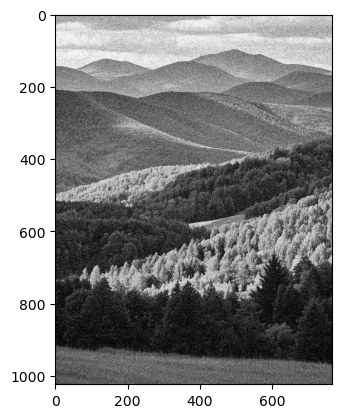

In [36]:
noise = np.random.randint(-50, 51, size=(image_gray.shape[0], image_gray.shape[1]), dtype=int)
image_uniform = np.clip(image_gray.astype(np.int16) + noise, 0, 255).astype(np.uint8)

plt.imshow(image_uniform, cmap="gray")

# MSE, SSIM зашумлённых картинок

In [41]:
mse_gauss = mean_squared_error(image_gray, image_noise_gauss)
(ssim, diff) = structural_similarity(image_gray, image_noise_gauss, full=True)
print(mse_gauss, ssim)

3494.8212509155273 0.19312786564145118


In [42]:
# salt and pepper
mse_sp = mean_squared_error(image_gray, image_sp)
(ssim_sp, diff) = structural_similarity(image_gray, image_sp, full=True)
print(mse_sp, ssim_sp)

412.82512791951496 0.6666681428280185


In [43]:
mse_uniform = mean_squared_error(image_gray, image_uniform)
(ssim_uniform, diff) = structural_similarity(image_gray, image_uniform, full=True)
print(mse_uniform, ssim_uniform)

787.2988357543945 0.3223561409241409


# Фильтры

## Медианный фильтр

### c шумом Гаусса

1037.5454177856445 0.30413742712393826


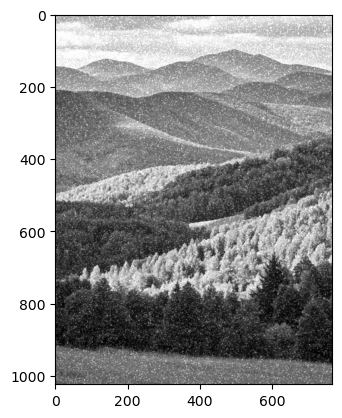

In [62]:
image_gauss_median_3 = cv2.medianBlur(image_noise_gauss, 3)

mse_gauss_median_3 = mean_squared_error(image_gray, image_gauss_median_3)
(ssim_gauss_median_3, diff) = structural_similarity(image_gray, image_gauss_median_3, full=True)

print(mse_gauss_median_3, ssim_gauss_median_3)
plt.imshow(image_gauss_median_3, cmap='gray')

626.6298713684082 0.4614292691854131


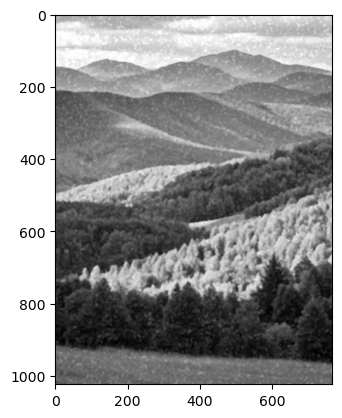

In [63]:
image_gauss_median_7 = cv2.medianBlur(image_noise_gauss, 7)

mse_gauss_median_7 = mean_squared_error(image_gray, image_gauss_median_7)
(ssim_gauss_median_7, diff) = structural_similarity(image_gray, image_gauss_median_7, full=True)

print(mse_gauss_median_7, ssim_gauss_median_7)
plt.imshow(image_gauss_median_7, cmap='gray')

### c постоянным шумом

374.3722457885742 0.3927077909088608


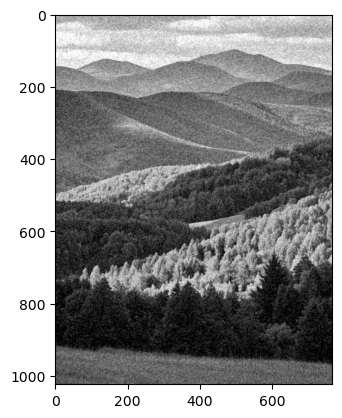

In [64]:
image_uniform_median_3 = cv2.medianBlur(image_uniform, 3)

mse_uniform_median_3 = mean_squared_error(image_gray, image_uniform_median_3)
(ssim_uniform_median_3, diff) = structural_similarity(image_gray, image_uniform_median_3, full=True)
print(mse_uniform_median_3, ssim_uniform_median_3)

plt.imshow(image_uniform_median_3, cmap='gray')

301.52645746866864 0.4989777570023414


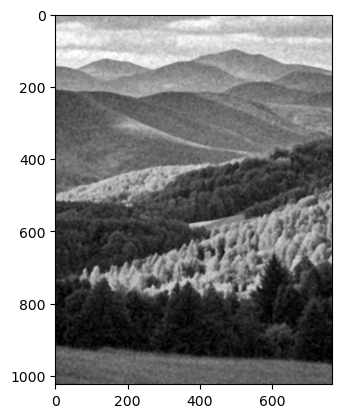

In [65]:
image_uniform_median_7 = cv2.medianBlur(image_uniform, 7)

mse_uniform_median_7 = mean_squared_error(image_gray, image_uniform_median_7)
(ssim_uniform_median_7, diff) = structural_similarity(image_gray, image_uniform_median_7, full=True)
print(mse_uniform_median_7, ssim_uniform_median_7)

plt.imshow(image_uniform_median_7, cmap='gray')

## Фильтр Гаусса

### c шумом Гаусса

1538.4962209065754 0.4148472593218904


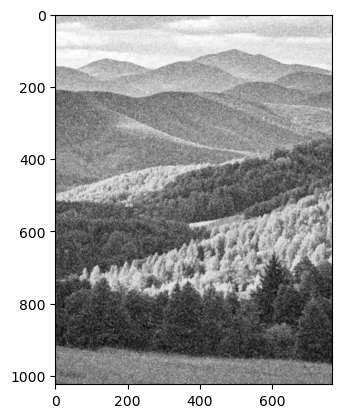

In [66]:
image_gauss_gauss_5 = cv2.GaussianBlur(image_noise_gauss, (5, 5), 0)

mse_gauss_gauss_5 = mean_squared_error(image_gray, image_gauss_gauss_5)
(ssim_gauss_gauss_5, diff) = structural_similarity(image_gray, image_gauss_gauss_5, full=True)

print(mse_gauss_gauss_5, ssim_gauss_gauss_5)
plt.imshow(image_gauss_gauss_5, cmap='gray')

1494.3992284138997 0.4714165589949116


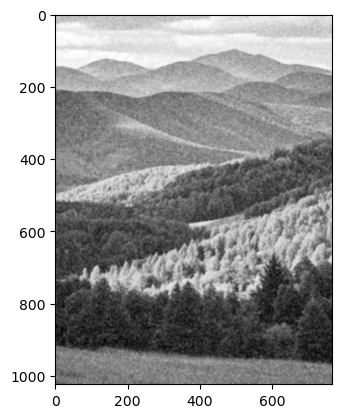

In [67]:
image_gauss_gauss_9 = cv2.GaussianBlur(image_noise_gauss, (9, 9), 0)

mse_gauss_gauss_9 = mean_squared_error(image_gray, image_gauss_gauss_9)
(ssim_gauss_gauss_9, diff) = structural_similarity(image_gray, image_gauss_gauss_9, full=True)

print(mse_gauss_gauss_9, ssim_gauss_gauss_9)
plt.imshow(image_gauss_gauss_9, cmap='gray')

### с постоянным шумом

219.03386815388998 0.5909435140125551


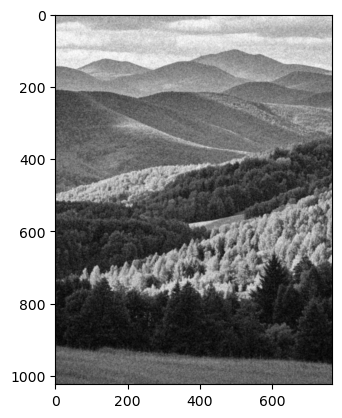

In [69]:
image_uniform_gauss_5 = cv2.GaussianBlur(image_uniform, (5, 5), 0)

mse_uniform_gauss_5 = mean_squared_error(image_gray, image_uniform_gauss_5)
(ssim_uniform_gauss_5, diff) = structural_similarity(image_gray, image_uniform_gauss_5, full=True)
print(mse_uniform_gauss_5, ssim_uniform_gauss_5)

plt.imshow(image_uniform_gauss_5, cmap='gray')

245.3620859781901 0.6031633909511458


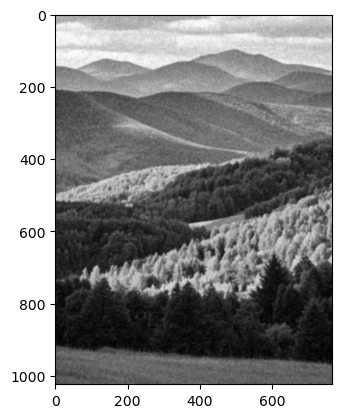

In [71]:
image_uniform_gauss_9 = cv2.GaussianBlur(image_uniform, (9, 9), 0)

mse_uniform_gauss_9 = mean_squared_error(image_gray, image_uniform_gauss_9)
(ssim_uniform_gauss_9, diff) = structural_similarity(image_gray, image_uniform_gauss_9, full=True)
print(mse_uniform_gauss_9, ssim_uniform_gauss_9)

plt.imshow(image_uniform_gauss_9, cmap='gray')

# Билатериальный фильтр

### с шумом Гаусса

1544.1267217000325 0.34759876852295407


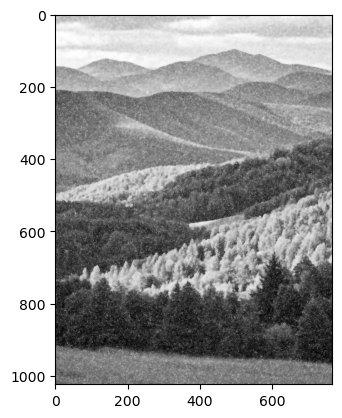

In [72]:
image_gauss_bilat_75 = cv2.bilateralFilter(image_noise_gauss, 9, 75, 75)

mse_gauss_bilat_75 = mean_squared_error(image_gray, image_gauss_bilat_75)
(ssim_gauss_bilat_75, diff) = structural_similarity(image_gray, image_gauss_bilat_75, full=True)
print(mse_gauss_bilat_75, ssim_gauss_bilat_75)

plt.imshow(image_gauss_bilat_75, cmap='gray')

1347.7280451456706 0.45987615118194763


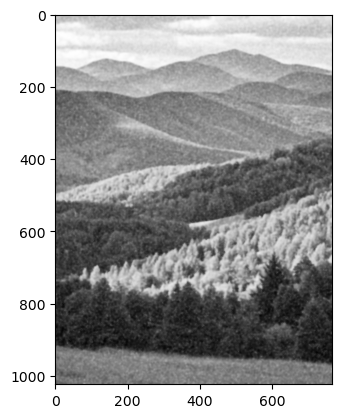

In [73]:
image_gauss_bilat_150 = cv2.bilateralFilter(image_noise_gauss, 9, 150, 150)

mse_gauss_bilat_150 = mean_squared_error(image_gray, image_gauss_bilat_150)
(ssim_gauss_bilat_150, diff) = structural_similarity(image_gray, image_gauss_bilat_150, full=True)
print(mse_gauss_bilat_150, ssim_gauss_bilat_150)

plt.imshow(image_gauss_bilat_150, cmap='gray')

### с постоянным шумом

185.4193572998047 0.6355791658656998


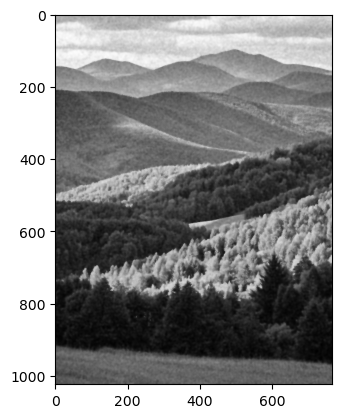

In [74]:
image_uniform_bilat_75 = cv2.bilateralFilter(image_uniform, 9, 75, 75)

mse_uniform_bilat_75 = mean_squared_error(image_gray, image_uniform_bilat_75)
(ssim_uniform_bilat_75, diff) = structural_similarity(image_gray, image_uniform_bilat_75, full=True)
print(mse_uniform_bilat_75, ssim_uniform_bilat_75)

plt.imshow(image_uniform_bilat_75, cmap='gray')

242.61486307779947 0.5969876408412356


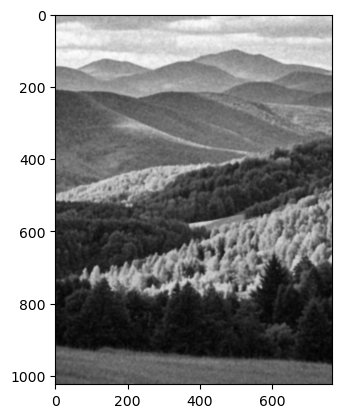

In [75]:
image_uniform_bilat_150 = cv2.bilateralFilter(image_uniform, 9, 150, 150)

mse_uniform_bilat_150 = mean_squared_error(image_gray, image_uniform_bilat_150)
(ssim_uniform_bilat_150, diff) = structural_similarity(image_gray, image_uniform_bilat_150, full=True)
print(mse_uniform_bilat_150, ssim_uniform_bilat_150)

plt.imshow(image_uniform_bilat_150, cmap='gray')

# Фильтр нелокальных средних

### с шумом Гаусса

3488.7164560953775 0.20770196110360448


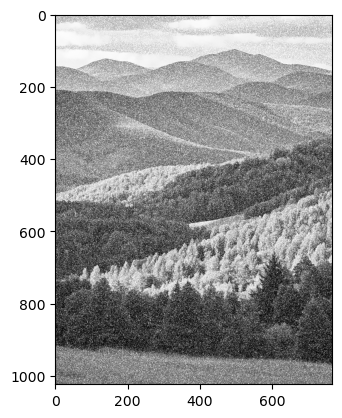

In [76]:
image_gauss_nlm_10 = cv2.fastNlMeansDenoising(image_noise_gauss, h = 10)

mse_gauss_nlm_10 = mean_squared_error(image_gray, image_gauss_nlm_10)
(ssim_gauss_nlm_10, diff) = structural_similarity(image_gray, image_gauss_nlm_10, full=True)
print(mse_gauss_nlm_10, ssim_gauss_nlm_10)

plt.imshow(image_gauss_nlm_10, cmap='gray')

3414.93648147583 0.2551647410697794


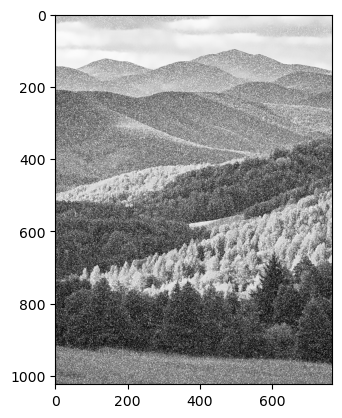

In [77]:
image_gauss_nlm_20 = cv2.fastNlMeansDenoising(image_noise_gauss, h = 20)

mse_gauss_nlm_20 = mean_squared_error(image_gray, image_gauss_nlm_20)
(ssim_gauss_nlm_20, diff) = structural_similarity(image_gray, image_gauss_nlm_20, full=True)
print(mse_gauss_nlm_20, ssim_gauss_nlm_20)

plt.imshow(image_gauss_nlm_20, cmap='gray')

### с постоянным шумом

783.1876703898112 0.323983101931576


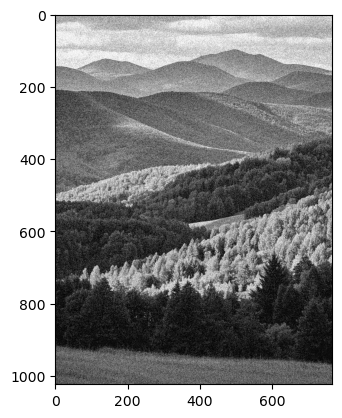

In [78]:
image_uniform_nlm_10 = cv2.fastNlMeansDenoising(image_uniform, h = 10)

mse_uniform_nlm_10 = mean_squared_error(image_gray, image_uniform_nlm_10)
(ssim_uniform_nlm_10, diff) = structural_similarity(image_gray, image_uniform_nlm_10, full=True)
print(mse_uniform_nlm_10, ssim_uniform_nlm_10)

plt.imshow(image_uniform_nlm_10, cmap='gray')

241.62383270263672 0.6255881677630921


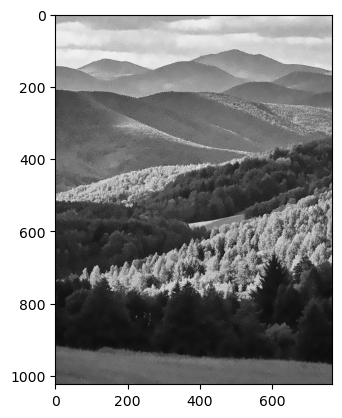

In [79]:
image_uniform_nlm_20 = cv2.fastNlMeansDenoising(image_uniform, h = 20)

mse_uniform_nlm_20 = mean_squared_error(image_gray, image_uniform_nlm_20)
(ssim_uniform_nlm_20, diff) = structural_similarity(image_gray, image_uniform_nlm_20, full=True)
print(mse_uniform_nlm_20, ssim_uniform_nlm_20)

plt.imshow(image_uniform_nlm_20, cmap='gray')

# Вывод

In [83]:
print("Сравнение результатов для шума Гаусса")
print(f"Медианный: MSE = {mse_gauss_median_3:.2f}, SSIM = {ssim_gauss_median_3:.4f}")
print(f"Гаусса: MSE = {mse_gauss_gauss_5:.2f}, SSIM = {ssim_gauss_gauss_5:.4f}")
print(f"Билатеральный: MSE = {mse_gauss_bilat_75:.2f}, SSIM = {ssim_gauss_bilat_75:.4f}")
print(f"Нелокальных средних: MSE = {mse_gauss_nlm_10:.2f}, SSIM = {ssim_gauss_nlm_10:.4f}")

Сравнение результатов для шума Гаусса
Медианный: MSE = 1037.55, SSIM = 0.3041
Гаусса: MSE = 1538.50, SSIM = 0.4148
Билатеральный: MSE = 1544.13, SSIM = 0.3476
Нелокальных средних: MSE = 3488.72, SSIM = 0.2077


In [84]:
print("Сравнение результатов для постоянного шума")
print(f"Медианный: MSE = {mse_uniform_median_3:.2f}, SSIM = {ssim_uniform_median_3:.4f}")
print(f"Гаусса: MSE = {mse_uniform_gauss_5:.2f}, SSIM = {ssim_uniform_gauss_5:.4f}")
print(f"Билатеральный: MSE = {mse_uniform_bilat_75:.2f}, SSIM = {ssim_uniform_bilat_75:.4f}")
print(f"Нелокальных средних: MSE = {mse_uniform_nlm_10:.2f}, SSIM = {ssim_uniform_nlm_10:.4f}")

Сравнение результатов для постоянного шума
Медианный: MSE = 374.37, SSIM = 0.3927
Гаусса: MSE = 245.36, SSIM = 0.6032
Билатеральный: MSE = 185.42, SSIM = 0.6356
Нелокальных средних: MSE = 783.19, SSIM = 0.3240
